<a href="https://colab.research.google.com/github/AntonDozhdikov/AntonDozhdikov/blob/main/KZP_OOVO_15_DGM_MADDPG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 🛠️ Установка библиотек (запускается один раз)
!pip install -q torch torchvision torchaudio numpy pandas matplotlib seaborn tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 78.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 56.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 75.8 MB/s eta 0:00:00


In [ ]:
# 📦 Импорт основных библиотек
import numpy as np, pandas as pd, torch, random, time, copy, math
from collections import deque
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass
from tqdm.auto import tqdm

# 🔒 Фиксация сидов для воспроизводимости
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 🎨 Глобальный стиль графиков
sns.set(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110

# 🧩 Общая конфигурация
@dataclass
class Config:
    n_universities: int = 15
    n_regions: int      = 15
    n_programs: int     = 10
    n_indicators: int   = 12

    # Параметры экономики и спроса
    base_federal_ratio: float = 0.70  # доля КЦП на старте
    ratio_delta:       float = 0.10   # год-к-году изменение
    demand_delta:      float = 0.10   # «нормальное» изменение спроса
    shock_p:           float = 0.05   # вероятность шока
    shock_mag:         float = 0.50   # амплитуда шока

    # RL-параметры
    episodes:    int   = 600
    steps:       int   = 24   # шагов внутри эпизода = «годы»
    gamma:       float = 0.95
    tau:         float = 0.01
    lr_actor:    float = 1e-3
    lr_critic:   float = 2e-3
    buffer_size: int   = 50_000
    batch:       int   = 256
    start_learn: int   = 512  # накопить опыта до начала обучения

CFG = Config()


In [ ]:
# 📈 10 причин колебаний спроса (произвольный набор)
DEMAND_FACTORS = [
    "Демография", "Рост ВРП", "Индустр. политика", "Гос-программы",
    "Технолог. инновации", "Миграция", "Конкуренция вузов",
    "Зарплаты в отрасли", "Инфраструктура", "Соц-тренды"
]

class UniversityEnv:
    """Мультиагентная среда: 15 вузов × 10 направлений × 15 регионов."""
    def __init__(self, cfg: Config):
        self.cfg = cfg
        self.year = 0
        self._reset_state()

    # 🔄 Сброс/инициализация
    def reset(self):
        self.year = 0
        self._reset_state()
        return self._get_obs()

    # 👣 Шаг среды.
    # actions — тензор shape=(n_universities, n_programs) ∈ [-1,1].
    # Каждый элемент → изменение процента КЦП, которое вуз хочет перераспределить.
    def step(self, actions: torch.Tensor):
        self.year += 1

        # 1) Применяем решения вузов, сдвигаем квоты в пределах ±10 %
        delta = (actions.cpu().numpy() * self.cfg.ratio_delta)
        self.federal_share = np.clip(self.federal_share + delta, 0., 1.)

        # 2) Обновляем региональный спрос
        self._update_demand()

        # 3) Вычисляем прибыль вуза и показатель «удовлетворён спрос»
        revenue, satisfied = self._financials()

        # 4) Награда агента — линейная комбинация
        reward = revenue * 1e-6 + satisfied  # масштабируем доход

        done = (self.year >= self.cfg.steps)
        return self._get_obs(), torch.tensor(reward, dtype=torch.float32), done, {}

    # 🏁 Табличное состояние для вывода
    def table(self):
        df = pd.DataFrame(self.indicators,
                          columns=[f"Ind_{i+1}" for i in range(self.cfg.n_indicators)])
        df.insert(0, "University", [f"U{i+1}" for i in range(self.cfg.n_universities)])
        df["Federal_%"] = self.federal_share.mean(axis=1).round(2)
        df["Profit_M"]  = (self.profit / 1e6).round(1)
        return df.head(15)

    # --- внутренние методы -------------------------------------------------- #
    def _reset_state(self):
        # ⏳ Случайные индикаторы (норм. распределение)
        self.indicators = np.random.normal(loc=0, scale=1,
                                           size=(self.cfg.n_universities, self.cfg.n_indicators))
        # 📊 Доля КЦП по программам
        self.federal_share = np.full((self.cfg.n_universities, self.cfg.n_programs),
                                     self.cfg.base_federal_ratio)
        # 📈 Спрос регионов: shape=(n_regions, n_programs)
        self.demand = np.random.uniform(100, 300, size=(self.cfg.n_regions, self.cfg.n_programs))
        self.profit = np.zeros(self.cfg.n_universities)

    def _update_demand(self):
        # «Нормальные» колебания ±10 %
        norm_noise = np.random.uniform(-self.cfg.demand_delta,
                                        self.cfg.demand_delta,
                                        size=self.demand.shape)
        self.demand *= (1 + norm_noise)

        # 🌩️ Шоки на отдельные направления
        shocks = np.random.rand(*self.demand.shape) < self.cfg.shock_p
        shock_dir = np.random.choice([-1, 1], size=self.demand.shape)
        self.demand *= np.where(shocks, 1 + shock_dir * self.cfg.shock_mag, 1)
        self.demand = np.clip(self.demand, 50, None)  # не опускаемся ниже 50

    def _financials(self):
        price_fed = 120_000  # ₽/студент (бюджет)
        price_comm = 200_000 # ₽/студент (коммерция)

        # Каждый вуз связан с регионом с тем же индексом
        # Соответственно, берем для каждого вуза спрос региона по всем программам
        regional_demand = self.demand[np.arange(self.cfg.n_universities), :]  # shape (15,10)

        # Формируем intake — количество студентов по вузам и программам (усреднённо умножаем на константу, например 50)
        intake = regional_demand * 50  # shape (15, 10)

        # Распределение между федеральным и коммерческим приемом по долям
        federal_intake = intake * self.federal_share  # shape (15, 10)
        comm_intake    = intake * (1 - self.federal_share)

        revenue = (federal_intake * price_fed + comm_intake * price_comm).sum(axis=1)  # по вузам

        self.profit += revenue
        # Как хорошо удовлетворили экономику: вычисляем по сумме всего спроса и набора
        total_intake = intake.sum()
        total_demand = self.demand.sum()
        satisfied = 1 - abs(total_intake - total_demand) / total_demand

        return revenue, satisfied

    def _get_obs(self):
        # Состояние — вектора индикаторов + доля КЦП + доход-в-текущий-год
        obs = np.hstack([self.indicators,
                         self.federal_share,
                         self.profit[:,None]/1e6])  # нормируем
        return torch.tensor(obs, dtype=torch.float32, device=DEVICE)


In [ ]:
class Actor(nn.Module):
    def __init__(self, state_dim, action_dim, hidden=128):
        super().__init__()
        self.fc1 = nn.Linear(state_dim, hidden)
        self.fc2 = nn.Linear(hidden, hidden)
        self.fc3 = nn.Linear(hidden, action_dim)
        self.reset()
    def reset(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight); nn.init.zeros_(m.bias)
    def forward(self, x):          # tanh → (-1,1)
        return torch.tanh(self.fc3(F.relu(self.fc2(F.relu(self.fc1(x))))))

class Critic(nn.Module):
    def __init__(self, state_dim, action_dim, n_agents, hidden=256):
        super().__init__()
        self.fc1 = nn.Linear((state_dim+action_dim)*n_agents, hidden)
        self.fc2 = nn.Linear(hidden, hidden)
        self.fc3 = nn.Linear(hidden, 1)
        self.reset()
    def reset(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight); nn.init.zeros_(m.bias)
    def forward(self, states, actions):
        x = torch.cat([states.reshape(states.size(0),-1),
                       actions.reshape(actions.size(0),-1)], dim=1)
        return self.fc3(F.relu(self.fc2(F.relu(self.fc1(x)))))


🧮 Начальное состояние вузов:


,University,Ind_1,Ind_2,Ind_3,Ind_4,Ind_5,Ind_6,Ind_7,Ind_8,Ind_9,Ind_10,Ind_11,Ind_12,Federal_%,Profit_M
0,U1,0.812862,0.629629,-0.828995,-0.560181,0.747294,0.610370,-0.020902,0.117327,1.277665,-0.591571,0.547097,-0.202193,0.7,0.0
1,U2,-0.217681,1.098777,0.825416,0.813510,1.305479,0.021004,0.681953,-0.310267,0.324166,-0.130143,0.096996,0.595157,0.7,0.0
2,U3,-0.818221,2.092387,-1.006017,-1.214189,1.158111,0.791663,0.624120,0.628346,-0.012247,-0.897254,0.075805,-0.677162,0.7,0.0
3,U4,0.975120,-0.147057,-0.825497,-0.321386,0.412931,-0.563725,-0.822220,0.243687,0.244967,-0.506943,-0.471038,0.232050,0.7,0.0
4,U5,-1.448084,-1.407464,-0.718444,-0.213447,0.310908,1.475356,0.857660,-0.159939,-0.019016,-1.002529,-0.018513,-0.288659,0.7,0.0
5,U6,0.322719,-0.827231,0.519347,1.532739,-0.108760,0.401712,0.690144,-0.401220,0.224092,0.012592,0.097676,-0.773010,0.7,0.0
6,U7,0.024510,0.497998,1.451144,0.959271,2.153182,-0.767348,0.872321,0.183342,2.189803,-0.808298,-0.839722,-0.599393,0.7,0.0
7,U8,-2.123896,-0.525755,-0.759133,0.150394,0.341756,1.876171,0.950424,-0.576904,-0.898415,0.491919,-1.320233,1.831459,0.7,0.0
8,U9,1.179440,-0.469176,-1.713135,1.353872,-0.114540,1.237816,-1.594428,-0.599375,0.005244,0.046981,-0.450065,0.622850,0.7,0.0
9,U10,-1.067620,-0.142379,0.120296,0.514439,0.711615,-1.124642,-1.534114,1.277677,0.332314,-0.748487,1.551152,0.115675,0.7,0.0


MADDPG Training:   0%|          | 0/600 [00:00<?, ?it/s]

/tmp/ipython-input-5-3578193777.py:33: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  return torch.tensor(acts, dtype=torch.float32, device=DEVICE)
/tmp/ipython-input-5-3578193777.py:93: UserWarning: Using a target size (torch.Size([256, 256, 1])) that is different to the input size (torch.Size([256, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_c = F.mse_loss(q_vals, y)


✅ MADDPG обучение завершено


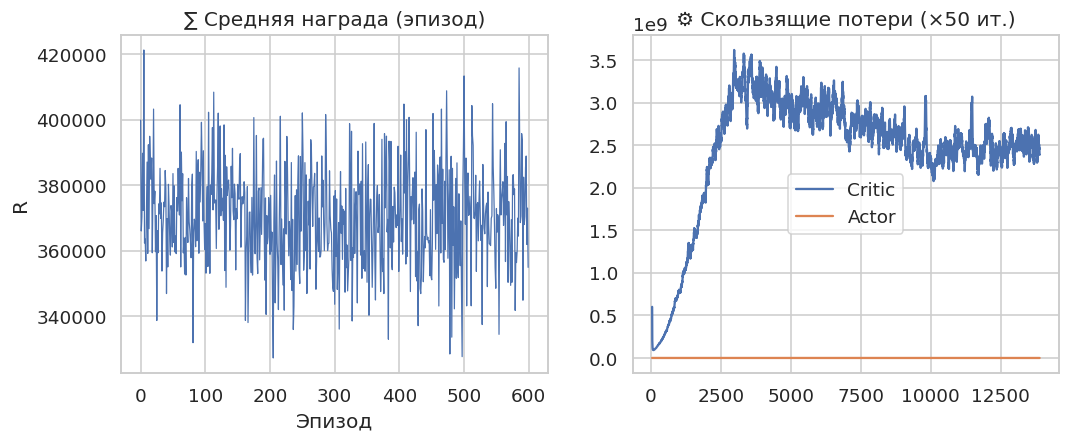

🏁 Итоговое состояние вузов:


,University,Ind_1,Ind_2,Ind_3,Ind_4,Ind_5,Ind_6,Ind_7,Ind_8,Ind_9,Ind_10,Ind_11,Ind_12,Federal_%,Profit_M
0,U1,-0.022132,0.788477,-1.050409,0.789601,0.152903,1.258806,-2.299616,1.330116,0.669285,0.597537,1.818564,-0.442211,0.7,337553.1
1,U2,1.341516,-0.361417,0.628837,0.061799,0.719503,0.947257,0.439731,-2.089361,0.025474,-0.192630,-1.016465,-0.277722,0.7,296442.5
2,U3,0.072714,-0.002533,-0.670345,1.131702,0.335736,-0.475749,0.199734,-0.270779,-0.881936,-1.494137,-0.610101,-0.764012,0.3,398390.0
3,U4,-0.201583,0.744352,-1.066367,0.973712,-1.538037,-0.643387,0.537620,0.093836,0.183137,0.225584,2.047086,-0.352722,0.3,380993.2
4,U5,0.392024,-0.816217,0.373366,1.355422,0.356217,0.229739,-0.879067,-0.493658,0.231299,-0.512276,-1.725235,-1.973629,0.6,329617.5
5,U6,-1.929180,0.665662,0.908303,0.001237,0.420079,2.443958,0.003180,-0.306525,-0.115166,-1.768815,-0.526949,1.133810,0.5,331974.9
6,U7,0.411111,0.374426,-0.747862,-0.899938,-1.245093,-1.402159,0.812210,-1.971154,-0.074783,-1.415213,0.229863,1.469615,0.9,270950.0
7,U8,-0.082173,0.481209,0.848341,-0.361077,1.138981,2.234184,-0.800332,-0.402931,0.193235,-0.912619,-0.108272,0.913021,0.7,337405.2
8,U9,-1.219063,0.207009,1.145165,1.141684,-1.720767,0.697098,-0.999189,-0.817265,0.371060,-0.530011,-1.371519,1.007605,0.6,319578.1
9,U10,0.038916,2.175860,-0.236822,0.411072,-1.159032,-0.094248,1.144219,0.744421,1.486791,-0.087089,0.575578,-0.460465,0.4,341049.6


In [ ]:
class MADDPG:
    def __init__(self, env: UniversityEnv, cfg: Config):
        self.env, self.cfg = env, cfg
        self.state_dim  = env.reset().shape[1]
        self.action_dim = cfg.n_programs
        # 🎭 Сетевые пары для каждого вуза
        self.actors, self.targets_a = [], []
        self.critics, self.targets_c = [], []
        for _ in range(cfg.n_universities):
            act  = Actor(self.state_dim, self.action_dim).to(DEVICE)
            targ = copy.deepcopy(act)
            self.actors.append(act); self.targets_a.append(targ)
            # Один общий Critic (централизованный)
        self.critic  = Critic(self.state_dim, self.action_dim,
                              cfg.n_universities).to(DEVICE)
        self.target_c = copy.deepcopy(self.critic)

        self.opt_a = [optim.Adam(a.parameters(), lr=cfg.lr_actor)
                      for a in self.actors]
        self.opt_c = optim.Adam(self.critic.parameters(), lr=cfg.lr_critic)

        self.memory = deque(maxlen=cfg.buffer_size)
        self.losses = {"critic":[], "actor":[]}
        self.rewards_epi = []

    # 🧠 Выбор действия с ε-жадным шумом
    def act(self, states, eps=0.1):
        acts = []
        for i, actor in enumerate(self.actors):
            a = actor(states[i]).detach().cpu().numpy()
            a += eps*np.random.normal(0, .2, size=a.shape)
            acts.append(a.clip(-1,1))
        return torch.tensor(acts, dtype=torch.float32, device=DEVICE)

    # 📒 Сохранение перехода
    def remember(self, *args): self.memory.append(args)

    # 📚 Обучение сети
    def learn(self):
        if len(self.memory) < self.cfg.start_learn:
            return

        batch = random.sample(self.memory, self.cfg.batch)
        states, actions, rewards, next_states, dones = zip(*batch)

        # Преобразуем в тензоры
        states      = torch.stack(states).to(DEVICE)        # (batch, n_agents, state_dim)
        actions     = torch.stack(actions).to(DEVICE)       # (batch, n_agents, action_dim)
        rewards     = torch.stack(rewards).to(DEVICE)       # (batch, n_agents)
        next_states = torch.stack(next_states).to(DEVICE)   # (batch, n_agents, state_dim)

        # Преобразуем dones.
        # Проверим сначала тип и размер:
        dones_list = list(dones)

        # Попытка определить размер: если булевы для каждого агента,
        # то должен быть tuple или list размером batch_size с вложенным списком длины n_agents.
        # Если нет, нужно поправить формат.

        # Если dones_list состоит из bool (размер batch_size), расширим до (batch_size,1),
        # иначе ожидаем список списков. Важно подготовить тензор shape (batch_size, n_agents)
        if isinstance(dones_list[0], bool):
            # если dones — просто bool для каждого перехода, расширяем по n_agents
            dones_t = torch.tensor(dones_list, dtype=torch.float32, device=DEVICE).unsqueeze(1)
            dones_t = dones_t.expand(-1, self.cfg.n_universities)  # (batch_size, n_agents)
        elif isinstance(dones_list[0], (list, tuple, np.ndarray)) or torch.is_tensor(dones_list[0]):
            # если dones — списки или тензоры по агентам: просто превращаем в тензор
            dones_t = torch.tensor(dones_list, dtype=torch.float32, device=DEVICE)
        else:
            raise ValueError(f"Непредвиденный формат dones: {dones_list[0]}")

        # Добавляем размерность для совместимости
        dones_t = dones_t.unsqueeze(-1)  # (batch_size, n_agents, 1)

        with torch.no_grad():
            next_actions = torch.stack(
                [target(next_states[:, i, :]) for i, target in enumerate(self.targets_a)],
                dim=1
            )  # (batch_size, n_agents, action_dim)

            q_next = self.target_c(next_states, next_actions)  # (batch_size, 1)

            rewards_exp = rewards.unsqueeze(-1)  # (batch_size, n_agents, 1)
            mean_rewards = rewards_exp.mean(dim=1, keepdim=True)  # (batch_size, 1, 1)

            # Используем done первого агента
            done_first_agent = dones_t[:, 0, :]  # (batch_size, 1)
            done_first_agent = done_first_agent.unsqueeze(-1)  # (batch_size, 1, 1)

            y = mean_rewards + self.cfg.gamma * (1 - done_first_agent) * q_next  # (batch_size, 1, 1)

        q_vals = self.critic(states, actions)  # (batch_size, 1)
        loss_c = F.mse_loss(q_vals, y)

        self.opt_c.zero_grad()
        loss_c.backward()
        self.opt_c.step()

        loss_a_tot = 0
        for i, actor in enumerate(self.actors):
            curr_actions = []
            for j, a in enumerate(self.actors):
                if j == i:
                    curr_actions.append(a(states[:, j, :]))
                else:
                    curr_actions.append(actions[:, j])
            curr_actions = torch.stack(curr_actions, dim=1)

            loss_a = -self.critic(states, curr_actions).mean()

            self.opt_a[i].zero_grad()
            loss_a.backward()
            self.opt_a[i].step()

            loss_a_tot += loss_a.item()

        with torch.no_grad():
            for target_actor, actor in zip(self.targets_a, self.actors):
                for tp, p in zip(target_actor.parameters(), actor.parameters()):
                    tp.data.mul_(1 - self.cfg.tau)
                    tp.data.add_(p.data * self.cfg.tau)

            for tp, p in zip(self.target_c.parameters(), self.critic.parameters()):
                tp.data.mul_(1 - self.cfg.tau)
                tp.data.add_(p.data * self.cfg.tau)

        self.losses["critic"].append(loss_c.item())
        self.losses["actor"].append(loss_a_tot / self.cfg.n_universities)




    # 🚀 Основной цикл
    def train(self):
        env = self.env
        pbar = tqdm(range(self.cfg.episodes), desc="MADDPG Training")
        for ep in pbar:
            state = env.reset()
            ep_reward = 0
            for _ in range(self.cfg.steps):
                action = self.act(state)
                next_s, reward, done, _ = env.step(action)
                self.remember(state, action, reward, next_s, done)
                self.learn()
                state = next_s
                ep_reward += reward.mean().item()
            self.rewards_epi.append(ep_reward)
            if ep % 50 == 0:
                pbar.set_postfix(R=ep_reward)
        print("✅ MADDPG обучение завершено")

### 1.3 Запуск + мониторинг
env1 = UniversityEnv(CFG)
maddp = MADDPG(env1, CFG)

print("🧮 Начальное состояние вузов:")
display(env1.table())

maddp.train()

# 📊 Графики
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

# График суммарной средней награды по эпизодам
ax[0].plot(maddp.rewards_epi, lw=0.8)
ax[0].set_title("∑ Средняя награда (эпизод)")
ax[0].set_xlabel("Эпизод")
ax[0].set_ylabel("R")

# График скользящих средних потерь для критика и актора
ax[1].plot(pd.Series(maddp.losses["critic"]).rolling(50).mean(), label="Critic")
ax[1].plot(pd.Series(maddp.losses["actor"]).rolling(50).mean(), label="Actor")
ax[1].legend()
ax[1].set_title("⚙️ Скользящие потери (×50 ит.)")

plt.show()

print("🏁 Итоговое состояние вузов:")
display(env1.table())


2. MADDP-DGM (коэволюция акторов + критика)
Дарвин–Гёдель-машина (DGM) организуется как генетический слой, который
каждые K эпизодов подвергает мутациям и скрещиванию веса сетей акторов и критика,
если метрика «прибыль × удовлетворение спроса» за последние W эпизодов застопорилась.

In [ ]:
@dataclass
class DGMcfg:
    K: int = 40          # период эволюции
    W: int = 30          # окно метрики
    elite_frac: float = .25
    mut_sigma: float = 0.02
DGM = DGMcfg()


In [ ]:
# 🔄 Кроссовер: обмен слоями между парами сетей
def crossover(netA, netB):
    child = copy.deepcopy(netA)
    for pa, pb, pc in zip(netA.parameters(), netB.parameters(), child.parameters()):
        mask = torch.rand_like(pa) > .5
        pc.data.copy_( torch.where(mask, pa, pb) )
    return child

# 🌱 Мутация Гаусса
def mutate(net, sigma=DGM.mut_sigma):
    for p in net.parameters():
        noise = torch.randn_like(p) * sigma
        p.data.add_(noise)
    return net


In [ ]:
class MADDPG_DGM(MADDPG):
    def evolve(self, gen_idx):
        # Вычислим фитнес последних W эпизодов
        fit = np.array(self.rewards_epi[-DGM.W:])
        if len(fit) < DGM.W:
            return  # мало данных для эволюции
        trend = fit.mean()
        if trend < np.percentile(self.rewards_epi, 60):
            print(f"🌱 DGM-Эволюция @ эпизод {gen_idx}")
            elite_count = int(CFG.n_universities * DGM.elite_frac)
            elite_count = min(elite_count, len(fit))  # fix: не превышаем размер fit
            idxs = np.argsort(fit)[-elite_count:]
            elite = [copy.deepcopy(self.actors[i % len(self.actors)]) for i in idxs]
            children = []
            while len(children) < CFG.n_universities - len(elite):
                a, b = random.sample(elite, 2)
                child = mutate(crossover(a, b))
                children.append(child)
            self.actors = elite + children
            self.critic = mutate(copy.deepcopy(self.critic))
            self.opt_c = optim.Adam(self.critic.parameters(), lr=CFG.lr_critic)
            self.targets_a = [copy.deepcopy(a) for a in self.actors]
            self.target_c = copy.deepcopy(self.critic)

    def train(self):
        env = self.env
        pbar = tqdm(range(CFG.episodes), desc="MADDP-DGM Training")  # Удалили обратный слеш
        for ep in pbar:
            state = env.reset()
            ep_reward = 0
            for _ in range(CFG.steps):
                action = self.act(state, eps=0.05)          # Меньше шума
                next_s, r, d, _ = env.step(action)
                self.remember(state, action, r, next_s, d)
                self.learn()
                state = next_s
                ep_reward += r.mean().item()
            self.rewards_epi.append(ep_reward)
            if ep % DGM.K == 0 and ep > 0:
                self.evolve(ep)
            if ep % 50 == 0:
                pbar.set_postfix(R=ep_reward)
        print("✅ MADDP-DGM обучение завершено")


🧮 Стартовое состояние DGM:


,University,Ind_1,Ind_2,Ind_3,Ind_4,Ind_5,Ind_6,Ind_7,Ind_8,Ind_9,Ind_10,Ind_11,Ind_12,Federal_%,Profit_M
0,U1,-1.017097,-1.606768,-0.367572,-1.094056,0.661730,1.097041,0.238987,0.151689,-1.085985,1.614246,-0.208014,1.078591,0.7,0.0
1,U2,-0.310618,0.060414,-1.082539,-0.112020,-1.293328,0.639005,-0.328191,-0.594768,-0.954998,0.148749,0.221791,1.921311,0.7,0.0
2,U3,0.224604,-0.171763,1.083028,0.585462,-0.763510,0.370335,0.309081,0.691246,0.233667,-0.843609,0.115953,1.817646,0.7,0.0
3,U4,0.935436,-1.023267,0.467217,0.379298,-1.523269,1.392501,1.382987,0.041436,0.319444,-0.576117,2.419516,-0.046718,0.7,0.0
4,U5,1.131418,-0.597041,-0.923436,-0.738645,0.805629,-0.326118,-1.805438,0.613290,1.355799,0.056738,2.654119,-0.591119,0.7,0.0
5,U6,0.000486,0.978032,0.614263,0.322686,0.326691,-0.375652,0.936211,-0.815738,1.407522,1.323357,-0.047853,-0.177242,0.7,0.0
6,U7,0.175904,-0.488250,0.066941,-0.267331,0.153310,1.522168,0.764970,-1.477279,-0.186269,1.334226,2.485962,-0.257521,0.7,0.0
7,U8,-1.386860,-0.139098,2.841421,0.079149,0.551794,-0.218762,1.669849,0.406396,1.624772,0.098515,0.973391,-0.509281,0.7,0.0
8,U9,0.205249,-0.173686,-0.249758,0.779476,-0.600404,0.234989,0.647598,-1.513944,1.189642,0.678289,-0.847597,-0.150077,0.7,0.0
9,U10,-0.113784,-0.736069,-0.571232,-1.250812,-0.774426,2.702249,-1.391362,-0.699862,-0.322278,1.469706,-0.184402,1.471152,0.7,0.0


MADDP-DGM Training:   0%|          | 0/600 [00:00<?, ?it/s]

/tmp/ipython-input-5-3578193777.py:93: UserWarning: Using a target size (torch.Size([256, 256, 1])) that is different to the input size (torch.Size([256, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_c = F.mse_loss(q_vals, y)


🌱 DGM-Эволюция @ эпизод 40
🌱 DGM-Эволюция @ эпизод 80
🌱 DGM-Эволюция @ эпизод 120
🌱 DGM-Эволюция @ эпизод 160
🌱 DGM-Эволюция @ эпизод 200
🌱 DGM-Эволюция @ эпизод 240
🌱 DGM-Эволюция @ эпизод 320
🌱 DGM-Эволюция @ эпизод 440
🌱 DGM-Эволюция @ эпизод 480
🌱 DGM-Эволюция @ эпизод 520
🌱 DGM-Эволюция @ эпизод 560
✅ MADDP-DGM обучение завершено


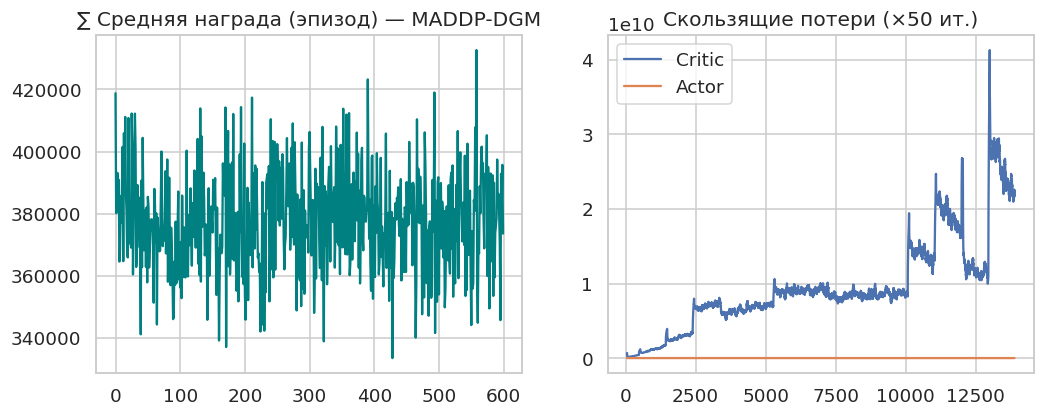

🏁 Итоговое состояние вузов (DGM):


,University,Ind_1,Ind_2,Ind_3,Ind_4,Ind_5,Ind_6,Ind_7,Ind_8,Ind_9,Ind_10,Ind_11,Ind_12,Federal_%,Profit_M
0,U1,-0.886958,1.340186,-1.642681,0.910817,-0.252502,-0.346202,-1.664160,0.170574,1.426797,0.473389,-0.442721,0.361424,0.5,435185.6
1,U2,-0.263193,-0.411838,-0.614943,0.622300,0.034601,2.191814,0.109901,-0.458190,-0.866472,-0.599806,0.498939,-0.718001,0.5,475521.0
2,U3,2.534323,-0.728872,-0.529155,-0.657116,-1.068796,-0.912959,0.626963,0.739255,0.846891,1.313554,0.174501,0.228490,0.5,542504.8
3,U4,0.478128,-1.061040,-0.010391,-0.193469,-1.529913,-0.340078,0.549724,-0.395976,-0.093660,-0.464037,1.741741,2.144803,0.5,453553.4
4,U5,2.084570,-0.518089,-0.560372,-0.633135,-0.924716,1.629809,-0.978438,0.683734,-0.560269,0.212682,-0.648671,0.472291,0.5,351207.9
5,U6,0.073425,0.211918,0.252502,1.187465,0.355183,-1.266695,1.198478,-0.255021,0.262699,0.456029,-1.865122,0.546695,0.5,309306.0
6,U7,1.481018,-0.399970,-0.882112,0.296158,1.606830,0.773071,-0.576879,-0.521141,0.917426,1.639826,0.027433,-0.669422,0.5,355240.7
7,U8,0.680453,-0.620497,-0.841889,0.942090,0.344805,0.315347,1.149960,0.707157,-0.545086,-0.830525,0.510272,0.411160,0.5,404942.6
8,U9,-0.165200,-0.354064,-1.659077,0.668915,1.699130,1.615760,-1.440732,-1.806680,-1.399640,0.169972,-1.158136,0.203049,0.5,332891.5
9,U10,0.380514,0.286859,0.783529,0.038719,-0.515619,1.268275,-0.096615,0.153241,-0.278342,-0.555121,0.080682,0.281416,0.5,239955.8


In [ ]:
env2  = UniversityEnv(CFG)
dgmad = MADDPG_DGM(env2, CFG)
print("🧮 Стартовое состояние DGM:")      # убрали лишний "\\"
display(env2.table())

dgmad.train()

# 📊 Графики
fig,ax = plt.subplots(1,2, figsize=(11,4))
ax[0].plot(dgmad.rewards_epi, color="teal")
ax[0].set_title("∑ Средняя награда (эпизод) — MADDP-DGM")
ax[1].plot(pd.Series(dgmad.losses["critic"]).rolling(50).mean(), label="Critic")
ax[1].plot(pd.Series(dgmad.losses["actor"]).rolling(50).mean(), label="Actor")
ax[1].legend(); ax[1].set_title("Скользящие потери (×50 ит.)")
plt.show()

print("🏁 Итоговое состояние вузов (DGM):")     # также убрали лишний "\\"
display(env2.table())


🔬 Сводный рост награды:


,Episode,MADDPG,MADDP-DGM
595,595,385313.538086,345619.624023
596,596,388882.003906,392836.081055
597,597,361948.599609,381792.309570
598,598,373005.577148,395704.435547
599,599,354943.297852,373526.859375


⏱️ MADDPG:     370533  средняя эпизодическая награда
⏱️ MADDP-DGM:  377566  средняя эпизодическая награда


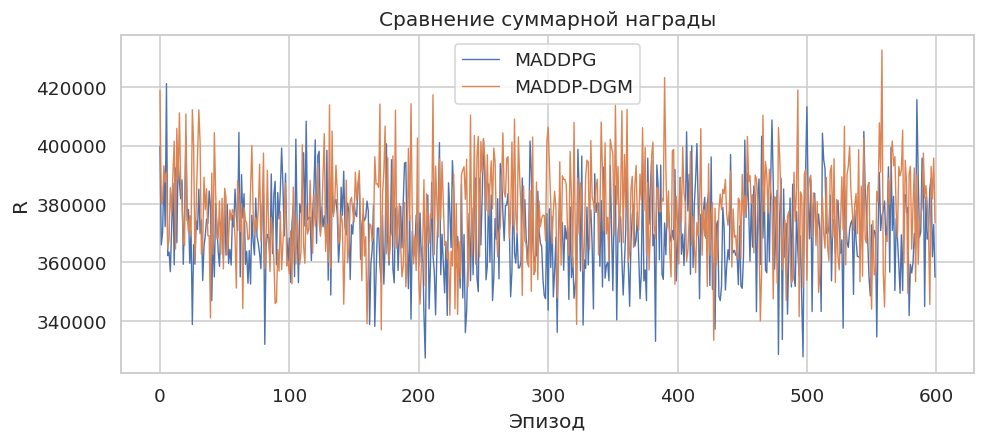

In [ ]:
# 📉 Сводные метрики
df_cmp = pd.DataFrame({
    "Episode": np.arange(CFG.episodes),
    "MADDPG": maddp.rewards_epi,
    "MADDP-DGM": dgmad.rewards_epi
})
print("🔬 Сводный рост награды:")
display(df_cmp.tail())

# ⏱️ Время обучения
print(f"⏱️ MADDPG:    {sum(maddp.rewards_epi)/CFG.episodes:7.0f}  средняя эпизодическая награда")
print(f"⏱️ MADDP-DGM: {sum(dgmad.rewards_epi)/CFG.episodes:7.0f}  средняя эпизодическая награда")

# 📊 Общий график сравнения
plt.figure(figsize=(10, 4))
plt.plot(df_cmp["Episode"], df_cmp["MADDPG"], label="MADDPG", lw=0.9)
plt.plot(df_cmp["Episode"], df_cmp["MADDP-DGM"], label="MADDP-DGM", lw=0.9)
plt.legend()
plt.title("Сравнение суммарной награды")
plt.xlabel("Эпизод")
plt.ylabel("R")
plt.show()